
# Download and Plot SGPS Proton Flux Data

Download, read, and plot proton flux from SGPS L2 data.


Import modules



IMPORT DATA FIRST

wget --recursive --no-clobber --no-parent --accept nc -e robots=off https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/goes18/l2/data/sgps-l2-avg5m/2026/01/

In [ ]:
import os
import requests
import netCDF4 as nc
import xarray as xr
import numpy as np
import cftime
import matplotlib.pyplot as plt
from matplotlib import colors, gridspec
import matplotlib.dates as mdates
from avg import filter_time_range
from avg import filter_n_frames
from plotting import *

Download, read, and get relevant data from files



In [11]:
import glob
sgps_data_path = "/home/jacob/noncarr/data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/goes18/l2/data/sgps-l2-avg5m/**/**/*.nc"

filepaths = glob.glob(sgps_data_path, recursive=True)

# MCP TIME SELECTION
start_datetime_str = '2025-12-19T00:00:00'
end_datetime_str = '2025-12-23T00:00:00'
n_frames_min = 0


proton_diff_flux_west = []
proton_diff_flux_east = []
proton_int_flux = []
time = []

#filepaths = [sgps_data_path + file for file in files]
#filepaths = get_filenames(sgps_data_path)

for filepath in filepaths:
    # Download `filename` if it does not exist locally
    #if not os.path.exists(filename):
    #    with open(filename, "wb") as f:
    #        r = requests.get(url_path + filename)
    #        f.write(r.content)

    # Load data from file
    sgps_data = nc.Dataset(filepath)

    # Get flux data
    proton_diff_flux_west.append(sgps_data['AvgDiffProtonFlux'][:, 0, :])
    proton_diff_flux_east.append(sgps_data['AvgDiffProtonFlux'][:, 1, :])
    proton_int_flux.append(sgps_data['AvgIntProtonFlux'][:])

    # Get timestamps
    # Two different time variable names may have been used
    try:
        time.append(sgps_data['L2_SciData_TimeStamp'][:])
    except IndexError:
        time.append(sgps_data['time'][:])

# Convert list of arrays into single array
proton_diff_flux_west = np.ma.concatenate(proton_diff_flux_west)
proton_diff_flux_east = np.ma.concatenate(proton_diff_flux_east)
proton_int_flux = np.ma.concatenate(proton_int_flux)
time = np.ma.concatenate(time)

# replace zeros with nans
proton_diff_flux_west = np.where(proton_diff_flux_west < 1.e-12, np.nan, proton_diff_flux_west)
proton_diff_flux_east = np.where(proton_diff_flux_east < 1.e-12, np.nan, proton_diff_flux_east)
proton_int_flux = np.where(proton_int_flux < 1.e-12, np.nan, proton_int_flux)

# Convert J2000 time to python datetime
time = cftime.num2pydate(time[:], sgps_data['time'].units)


# Convert the strings to datetime objects
start_datetime = np.datetime64(start_datetime_str)
end_datetime = np.datetime64(end_datetime_str)

ds = xr.open_dataset('products/WFI_FOV_AVG.nc')
mcp_rad_top = ds["fov_mean_top"].values
mcp_rad_bottom = ds["fov_mean_bottom"].values
print(ds["time"][3074])

mcp_rad_top = ds["fov_mean_top"].values
mcp_rad_bottom = ds["fov_mean_bottom"].values
datetimes = ds["observation"].values
n_frames = ds["n_frames"].values
ds.close()

datetimes = datetimes.astype('datetime64[ns]')

# Filter data by time range
mcp_rad_top = filter_time_range(mcp_rad_top, datetimes, start_datetime, end_datetime)
mcp_rad_bottom = filter_time_range(mcp_rad_bottom, datetimes, start_datetime, end_datetime)
n_frames = filter_time_range(n_frames, datetimes, start_datetime, end_datetime)
datetimes = filter_time_range(datetimes, datetimes, start_datetime, end_datetime)

# Filter data by n_frames
mcp_rad_top = filter_n_frames(mcp_rad_top, n_frames, n_frames_min)
mcp_rad_bottom = filter_n_frames(mcp_rad_bottom, n_frames, n_frames_min)
datetimes_filtered = filter_n_frames(datetimes, n_frames, n_frames_min)

<xarray.DataArray 'time' ()> Size: 8B
[1 values with dtype=datetime64[ns]]
Coordinates:
    observation  datetime64[ns] 8B 2026-01-06T14:03:17


Plot SGPS flux



/tmp/ipykernel_496523/2526126630.py:100: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim([ylims[0], 1.4*ylims[1]])


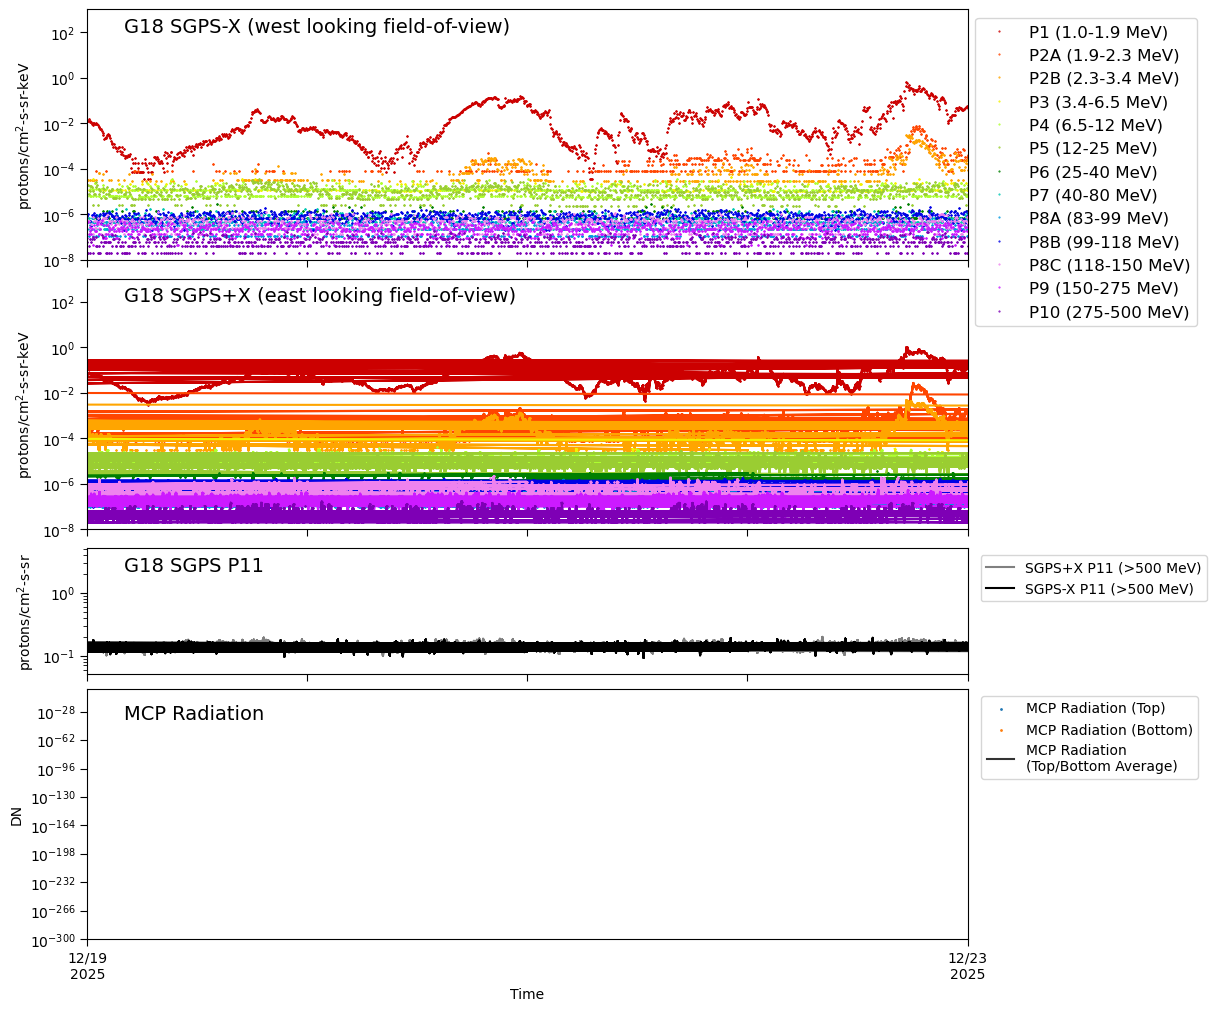

In [15]:
plt.figure(1, figsize=[12, 10], layout='constrained')
gridspec.GridSpec(7, 1)


# important variables
n_frames_min = 0

# Plot differential flux
NUM_DIFF_CHANNELS = 13

chan_colors = [[.8, 0., 0.], colors.to_rgba('orangered')[0:3], colors.to_rgba('orange')[0:3],
               [.95, .95, .0], colors.to_rgba('greenyellow')[0:3], colors.to_rgba('yellowgreen')[0:3],
               colors.to_rgba('green')[0:3], [0., .78, .7], [0., .6, .88], [0., 0., .9],
               colors.to_rgba('violet')[0:3], [0.8, .1, 1.0], [0.49411765, 0., 0.70980392]]

chan_labels = ['P1 (1.0-1.9 MeV)', 'P2A (1.9-2.3 MeV)', 'P2B (2.3-3.4 MeV)', 'P3 (3.4-6.5 MeV)',
               'P4 (6.5-12 MeV)', 'P5 (12-25 MeV)', 'P6 (25-40 MeV)', 'P7 (40-80 MeV)',
               'P8A (83-99 MeV)', 'P8B (99-118 MeV)', 'P8C (118-150 MeV)', 'P9 (150-275 MeV)',
               'P10 (275-500 MeV)']

# SGPS-X (west)
ax1 = plt.subplot2grid((7, 1), (0, 0), colspan=1, rowspan=2)
for i in range(NUM_DIFF_CHANNELS):
    plt.plot(time, proton_diff_flux_west[:, i], color=chan_colors[i], label=chan_labels[i], marker='o', linestyle='none', ms=0.5)
textstr = 'G18 SGPS-X (west looking field-of-view)'
ax1.text(0.042, 0.97, textstr, transform=ax1.transAxes, fontsize=14, verticalalignment='top')
#ax1.xaxis.set_minor_locator(mdates.HourLocator())
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.tick_params(which = 'minor', length=3)
ax1.tick_params(which = 'major', length=5)
ax1.set_xlim(time[0], time[-1])
ax1.tick_params(labelbottom=False)
plt.yscale('log')
plt.ylim([1.e-8, 1.e3])
plt.ylabel('protons/cm$^2$-s-sr-keV')

leg1 = ax1.legend(loc='upper right', bbox_to_anchor=(1.27, 1), prop={'size': 12})
leg1.set_in_layout(False)

# SGPS+X (east)
ax2 = plt.subplot2grid((7, 1), (2, 0), colspan=1, rowspan=2)
for i in range(NUM_DIFF_CHANNELS):
    plt.plot(time, proton_diff_flux_east[:, i], color=chan_colors[i], label=chan_labels[i], marker='o', ms=0.5)
textstr = 'G18 SGPS+X (east looking field-of-view)'
ax2.text(0.042, 0.97, textstr, transform=ax2.transAxes, fontsize=14, verticalalignment='top')
#ax2.xaxis.set_minor_locator(mdates.HourLocator())
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.tick_params(which = 'minor', length=3)
ax2.tick_params(which = 'major', length=5)
ax2.set_xlim(time[0], time[-1])
ax2.tick_params(labelbottom=False)
plt.yscale('log')
plt.ylim([1.e-8, 1.e3])
plt.ylabel('protons/cm$^2$-s-sr-keV')

# Plot integral flux
ax3 = plt.subplot2grid((7, 1), (4, 0), colspan=1, rowspan=1)
plt.plot(time, proton_int_flux[:, 1], color='grey', label='SGPS+X P11 (>500 MeV)')
plt.plot(time, proton_int_flux[:, 0], color='k', label='SGPS-X P11 (>500 MeV)')
textstr = 'G18 SGPS P11'
ax3.text(0.042, 0.94, textstr, transform=ax3.transAxes, fontsize=14, verticalalignment='top')
#ax3.xaxis.set_minor_locator(mdates.HourLocator())
ax3.xaxis.set_major_locator(mdates.DayLocator())
#ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax3.tick_params(which = 'minor', length=3)
ax3.tick_params(which = 'major', length=5)
ax3.set_xlim(time[0], time[-1])
ax3.tick_params(labelbottom=False)
#plt.xlabel('2026 (UT hours)')
plt.ylabel('protons/cm$^2$-s-sr')
plt.yscale('log')
ylims = ax3.get_ylim()
plt.ylim([ylims[0], 1.4*ylims[1]])

ax3.legend(loc='upper right', bbox_to_anchor=(1.28, 1), prop={'size': 10})

# Plot MCP radiation
ax4 = plt.subplot2grid((7, 1), (5, 0), colspan=1, rowspan=2)
plt.scatter(datetimes_filtered, mcp_rad_top, label='MCP Radiation (Top)', s=1)
plt.scatter(datetimes, mcp_rad_bottom, label='MCP Radiation (Bottom)', s=1)
plt.plot(datetimes, np.mean([mcp_rad_top, mcp_rad_bottom], axis=0), label='MCP Radiation\n(Top/Bottom Average)', color='black', alpha=0.8)
textstr = 'MCP Radiation'
ax4.text(0.042, 0.94, textstr, transform=ax4.transAxes, fontsize=14, verticalalignment='top')
#ax4.xaxis.set_minor_locator(mdates.DayLocator())
ax4.xaxis.set_major_locator(mdates.DayLocator(bymonthday=(1, 15)))
#ax4.xaxis.set_major_locator(mdates.DayLocator())
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d\n%Y'))
#ax4.tick_params(which = 'minor', length=3)
ax4.tick_params(which = 'major', length=5)
ax4.set_xlim(time[0], time[-1])
plt.xlabel('Time')

ax4.legend(bbox_to_anchor=(1.27, 1), prop={'size': 10})

#fig.autofmt_xdate()

plt.ylabel('DN')
plt.yscale('log')
ylims = ax4.get_ylim()
plt.ylim([ylims[0], 1.4*ylims[1]])

ax1.set_xlim([start_datetime, end_datetime])
ax2.set_xlim([start_datetime, end_datetime])
ax3.set_xlim([start_datetime, end_datetime])
ax4.set_xlim([start_datetime, end_datetime])



plt.show()

In [13]:
"""
mcp_goes18_regression.py
------------------------
Regression analysis: MCP radiation (DN) as a function of GOES-18 SGPS proton flux.
Designed to run after the SGPS plotting script, which leaves the following variables
in scope:
    time                    : np.ndarray of datetime objects (GOES-18 L2 5-min cadence)
    proton_diff_flux_west   : np.ma.MaskedArray, shape (N, 13) [SGPS-X]
    proton_diff_flux_east   : np.ma.MaskedArray, shape (N, 13) [SGPS+X]
    proton_int_flux         : np.ma.MaskedArray, shape (N, 2)  [col 0 = west, col 1 = east]

Both radiation_data-top.nc and radiation_data-bottom.nc are loaded fresh here.

Channel selection notes (per GOES-18 SGPS Full Maturity README, 2023-09-13):
    EXCLUDED:
      SGPS+X (east) P8C [idx 10], P9 [idx 11], P10 [idx 12]  -- temp-dependent ±30%
      SGPS-X (west) P8C [idx 10], P9 [idx 11]                -- factor 2-3 high
      SGPS+X (east) P10 [idx 12]                             -- no response in SEP events
      P5 [idx 5] (both)                                      -- electron contamination
    USED:
      SGPS-X (west)  : P1-P4 [0:4], P6-P7 [6:8], P8A [8], P8B [9]  (T1+T2, well-validated)
      SGPS+X (east)  : P1-P4 [0:4], P6-P7 [6:8], P8A [8], P8B [9]
      P11 integral   : SGPS-X only [col 0]                           (best GCR channel)
"""

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from scipy import stats
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


# =============================================================================
# 0. CHANNEL CONFIGURATION (README-informed)
# =============================================================================

CHAN_LABELS = [
    'P1 (1.0-1.9 MeV)',   'P2A (1.9-2.3 MeV)', 'P2B (2.3-3.4 MeV)',
    'P3 (3.4-6.5 MeV)',   'P4 (6.5-12 MeV)',    'P5 (12-25 MeV)',
    'P6 (25-40 MeV)',      'P7 (40-80 MeV)',      'P8A (83-99 MeV)',
    'P8B (99-118 MeV)',    'P8C (118-150 MeV)',   'P9 (150-275 MeV)',
    'P10 (275-500 MeV)',
]

# Indices of usable differential channels
WEST_GOOD_DIFF = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
EAST_GOOD_DIFF = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# Feature labels for regression output
FEATURE_LABELS_WEST = [f"W_{CHAN_LABELS[i]}" for i in WEST_GOOD_DIFF]
FEATURE_LABELS_EAST = [f"E_{CHAN_LABELS[i]}" for i in EAST_GOOD_DIFF]
FEATURE_LABELS_ALL  = FEATURE_LABELS_WEST + FEATURE_LABELS_EAST + ["P11_west (>500 MeV)"]


# =============================================================================
# 1. HELPER FUNCTIONS
# =============================================================================

def load_radiation_dataset(nc_path, start_dt_str, end_dt_str, n_frames_min=0):
    """Load and filter a Carruthers MCP radiation NetCDF dataset."""
    ds = xr.open_dataset(nc_path)
    mcp_rad_top  = ds["mcp_rad_top"].values
    mcp_rad_bottom = ds["mcp_rad_bottom"].values
    datetimes = ds["observation"].values.astype("datetime64[ns]")
    n_frames  = ds["n_frames"].values
    ds.close()

    start = np.datetime64(start_dt_str)
    end   = np.datetime64(end_dt_str)
    mask  = (datetimes >= start) & (datetimes <= end) & (n_frames >= n_frames_min)

    return datetimes[mask], mcp_rad_top[mask], datetimes[mask], mcp_rad_bottom[mask]


def dt_to_numeric(dt_array):
    """Convert datetime64 or Python datetime array to float seconds since first element."""
    dt64 = np.array(dt_array, dtype="datetime64[ns]")
    return (dt64 - dt64[0]).astype(np.float64) * 1e-9   # nanoseconds → seconds


def interpolate_goes_to_mcp(goes_time, goes_flux_2d, mcp_time):
    """
    Linearly interpolate each GOES-18 flux channel (columns of goes_flux_2d)
    onto the MCP observation timestamps.  NaN-safe: intervals with NaN on
    either bounding point are returned as NaN.

    Parameters
    ----------
    goes_time    : array-like of datetime objects, length N
    goes_flux_2d : (N, C) array of flux values (NaN for bad data)
    mcp_time     : array-like of datetime64[ns], length M

    Returns
    -------
    interp_flux  : (M, C) float array
    """
    goes_t_s = dt_to_numeric(np.array(goes_time, dtype="datetime64[ns]"))
    mcp_t_s  = dt_to_numeric(mcp_time)

    n_chan = goes_flux_2d.shape[1]
    out    = np.full((len(mcp_time), n_chan), np.nan)

    for c in range(n_chan):
        col  = np.asarray(goes_flux_2d[:, c], dtype=float)
        # Build valid-only arrays for interpolation
        valid = np.isfinite(col)
        if valid.sum() < 2:
            continue
        out[:, c] = np.interp(mcp_t_s, goes_t_s[valid], col[valid],
                               left=np.nan, right=np.nan)
    return out


def build_feature_matrix(goes_time, diff_west, diff_east, int_flux, mcp_time):
    """
    Interpolate selected GOES-18 channels to MCP timestamps and assemble
    a feature matrix X of shape (M, n_features).
    """
    # Select good channels
    west_sel = diff_west[:, WEST_GOOD_DIFF]
    east_sel = diff_east[:, EAST_GOOD_DIFF]
    p11_west = int_flux[:, 0:1]   # SGPS-X P11 only

    # Interpolate everything to MCP times
    X_west = interpolate_goes_to_mcp(goes_time, west_sel,  mcp_time)
    X_east = interpolate_goes_to_mcp(goes_time, east_sel,  mcp_time)
    X_p11  = interpolate_goes_to_mcp(goes_time, p11_west,  mcp_time)

    return np.hstack([X_west, X_east, X_p11])   # (M, n_features)


def log_transform(X, y):
    """
    Take log10 of X and y.  Rows where any value is non-positive or NaN are
    dropped. Returns (X_log, y_log, valid_mask).
    """
    valid = np.isfinite(y) & (y > 0)
    valid &= np.all(np.isfinite(X) & (X > 0), axis=1)
    return np.log10(X[valid]), np.log10(y[valid]), valid


def regression_report(name, y_true_log, y_pred_log, feature_names=None, coefs=None):
    """Print a tidy regression summary to stdout."""
    residuals = y_true_log - y_pred_log
    r2  = r2_score(y_true_log, y_pred_log)
    rmse = np.sqrt(np.mean(residuals**2))
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  N points : {len(y_true_log)}")
    print(f"  R²       : {r2:.4f}")
    print(f"  RMSE (log10 DN) : {rmse:.4f}  ({10**rmse:.2f}× in linear space)")
    if coefs is not None and feature_names is not None:
        print(f"\n  Coefficients (log10 space):")
        for fn, c in zip(feature_names, coefs):
            print(f"    {fn:<35s} : {c:+.4f}")
    print()


# =============================================================================
# 2. LOAD RADIATION DATA
# =============================================================================

START = start_datetime_str
END   = end_datetime_str
N_FRAMES_MIN = 0

print("Loading MCP radiation data...")
dt_top,    dn_top, dt_bottom, dn_bottom   = load_radiation_dataset("products/mcp_rad_data.nc",
                                               START, END, N_FRAMES_MIN)


print(f"  Top    : {len(dn_top)} observations")
print(f"  Bottom : {len(dn_bottom)} observations")


# =============================================================================
# 3. BUILD FEATURE MATRICES (interpolated GOES-18 → MCP timestamps)
# =============================================================================

print("\nInterpolating GOES-18 channels to MCP timestamps...")

X_top    = build_feature_matrix(time, proton_diff_flux_west, proton_diff_flux_east,
                                  proton_int_flux, dt_top)
X_bottom = build_feature_matrix(time, proton_diff_flux_west, proton_diff_flux_east,
                                  proton_int_flux, dt_bottom)

# P11-only feature (last column) for univariate model
P11_COL = -1


# =============================================================================
# 4. REGRESSION — UNIVARIATE (P11 only)
# =============================================================================
# P11 is the best-behaved quiet-time GCR channel and anchors both ends of
# the calibration curve.  A log-log regression tests the power-law hypothesis:
#   DN/s  ∝  Φ^α   →   log(DN) = α·log(Φ) + β

results = {}

for label, dt_arr, dn_arr, X_mat in [
        ("Top",    dt_top,    dn_top,    X_top),
        ("Bottom", dt_bottom, dn_bottom, X_bottom)]:

    print(f"\n--- Sensor: {label} ---")

    # ---- 4a. Univariate: P11 only ----
    X_p11_col = X_mat[:, -1:]
    X_p11_log, y_log, mask_p11 = log_transform(X_p11_col, dn_arr)

    slope, intercept, r_val, p_val, stderr = stats.linregress(
        X_p11_log[:, 0], y_log)
    y_pred_p11 = slope * X_p11_log[:, 0] + intercept

    regression_report(
        f"{label} — Univariate (P11 >500 MeV)",
        y_log, y_pred_p11,
        feature_names=["log10(P11_west)"],
        coefs=[slope]
    )
    print(f"  Power law: DN = 10^({intercept:.3f}) × Φ_P11^({slope:.3f})")

    # ---- 4b. Multivariate: all good channels ----
    X_all_log, y_all_log, mask_all = log_transform(X_mat, dn_arr)

    if X_all_log.shape[0] > X_all_log.shape[1] + 5:
        # Use Huber regression (robust to outliers from particle hit spikes)
        huber = HuberRegressor(epsilon=1.5, max_iter=500)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_all_log)
        huber.fit(X_scaled, y_all_log)
        y_pred_multi = huber.predict(X_scaled)

        # Recover unscaled coefficients for interpretability
        raw_coefs = huber.coef_ / scaler.scale_

        regression_report(
            f"{label} — Multivariate (all valid channels, Huber)",
            y_all_log, y_pred_multi,
            feature_names=FEATURE_LABELS_ALL,
            coefs=raw_coefs
        )
    else:
        print(f"  [!] Insufficient valid points for multivariate regression on {label}")
        huber = None

    # Store for plotting
    results[label] = {
        "dt":           dt_arr,
        "dn":           dn_arr,
        "X":            X_mat,
        "mask_p11":     mask_p11,
        "X_p11_log":    X_p11_log,
        "y_log_p11":    y_log,
        "y_pred_p11":   y_pred_p11,
        "slope_p11":    slope,
        "intercept_p11": intercept,
        "r2_p11":       r_val**2,
        "mask_all":     mask_all,
        "y_all_log":    y_all_log,
        "y_pred_multi": y_pred_multi if huber is not None else None,
        "r2_multi":     r2_score(y_all_log, y_pred_multi) if huber is not None else None,
        "huber":        huber,
        "scaler":       scaler if huber is not None else None,
    }


# =============================================================================
# 5. RESIDUAL DIAGNOSTICS
# =============================================================================

for label, res in results.items():
    resid_p11  = res["y_log_p11"] - res["y_pred_p11"]
    times_p11  = res["dt"][res["mask_p11"]]

    print(f"\n{label} P11 residuals:")
    print(f"  Mean  : {resid_p11.mean():.4f} log10-DN")
    print(f"  Std   : {resid_p11.std():.4f} log10-DN  ({10**resid_p11.std():.2f}× in linear)")
    print(f"  Skew  : {stats.skew(resid_p11):.3f}  (>0 → positive outliers from particle hits)")
    print(f"  Kurt  : {stats.kurtosis(resid_p11):.3f}  (>3 → heavy tails)")

    if res["y_pred_multi"] is not None:
        resid_multi = res["y_all_log"] - res["y_pred_multi"]
        print(f"\n{label} Multivariate residuals:")
        print(f"  Mean  : {resid_multi.mean():.4f}")
        print(f"  Std   : {resid_multi.std():.4f}  ({10**resid_multi.std():.2f}× in linear)")


# =============================================================================
# 6. PLOTTING
# =============================================================================

fig = plt.figure(figsize=(16, 14), layout="constrained")
gs  = GridSpec(3, 2, figure=fig, hspace=0.1, wspace=0.1)

COLORS = {"Top": "#1f77b4", "Bottom": "#d62728"}

for col_idx, (label, res) in enumerate(results.items()):
    color = COLORS[label]

    # ---- Panel (row 0): Time series overlay ----
    ax_ts = fig.add_subplot(gs[0, col_idx])

    # Plot P11 on primary y-axis
    goes_t_numeric = dt_to_numeric(np.array(time, dtype="datetime64[ns]"))
    mcp_t_numeric  = dt_to_numeric(res["dt"])
    p11_on_mcp     = np.interp(mcp_t_numeric,
                                goes_t_numeric,
                                np.asarray(proton_int_flux[:, 0], dtype=float),
                                left=np.nan, right=np.nan)

    ax_ts2 = ax_ts.twinx()
    ax_ts.plot(res["dt"], res["dn"], color=color, alpha=0.6, lw=0.8, label="MCP DN")
    ax_ts2.plot(res["dt"], p11_on_mcp, color="k", alpha=0.5, lw=0.8, ls="--", label="P11 flux")
    ax_ts.set_yscale("log")
    ax_ts2.set_yscale("log")
    ax_ts.set_ylabel("MCP DN", color=color)
    ax_ts2.set_ylabel("P11 flux (p/cm²-s-sr)", color="k")
    ax_ts.set_title(f"{label}: Time Series")
    ax_ts.xaxis.set_major_locator(mdates.DayLocator())
    ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    lines1, labs1 = ax_ts.get_legend_handles_labels()
    lines2, labs2 = ax_ts2.get_legend_handles_labels()
    ax_ts.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="upper left")

    # ---- Panel (row 1): Log-log scatter + P11 fit ----
    ax_sc = fig.add_subplot(gs[1, col_idx])

    ax_sc.scatter(10**res["X_p11_log"][:, 0], 10**res["y_log_p11"],
                  s=3, alpha=0.4, color=color, label="Observations")

    # Overplot power-law fit line
    x_fit = np.logspace(np.nanmin(res["X_p11_log"]),
                         np.nanmax(res["X_p11_log"]), 200)
    y_fit = 10**(res["slope_p11"] * np.log10(x_fit) + res["intercept_p11"])
    ax_sc.plot(x_fit, y_fit, color="k", lw=1.5,
               label=f"Fit: DN = 10^{res['intercept_p11']:.2f} × Φ^{res['slope_p11']:.2f}\n"
                     f"R² = {res['r2_p11']:.3f}")

    ax_sc.set_xscale("log")
    ax_sc.set_yscale("log")
    ax_sc.set_xlabel("SGPS-X P11 flux (p/cm²-s-sr)")
    ax_sc.set_ylabel("MCP DN")
    ax_sc.set_title(f"{label}: P11 Univariate (log-log)")
    ax_sc.legend(fontsize=8)

    # ---- Panel (row 2): Residual time series (P11 model) ----
    ax_res = fig.add_subplot(gs[2, col_idx])
    resid  = res["y_log_p11"] - res["y_pred_p11"]
    times_p11 = res["dt"][res["mask_p11"]]

    ax_res.scatter(times_p11, resid, s=2, alpha=0.4, color=color)
    ax_res.axhline(0,  color="k",    lw=1.0, ls="-")
    ax_res.axhline(+resid.std(),  color="grey", lw=0.8, ls="--")
    ax_res.axhline(-resid.std(),  color="grey", lw=0.8, ls="--")
    ax_res.set_xlabel("Time")
    ax_res.set_ylabel("Residual (log10 DN)")
    ax_res.set_title(f"{label}: P11 Residuals")
    ax_res.xaxis.set_major_locator(mdates.DayLocator())
    ax_res.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))

    # Annotate with residual statistics
    ann = (f"μ = {resid.mean():.3f}\nσ = {resid.std():.3f}\n"
           f"skew = {stats.skew(resid):.2f}")
    ax_res.text(0.97, 0.97, ann, transform=ax_res.transAxes,
                fontsize=8, va="top", ha="right",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

fig.suptitle("MCP Radiation vs. GOES-18 SGPS — Regression Analysis\n"
             "GOES-18 G18 | 2025-11-11 – 2025-11-14", fontsize=13, fontweight="bold")

plt.savefig("products/mcp_regression_analysis.png", dpi=150, bbox_inches="tight")
print("\nFigure saved to products/mcp_regression_analysis.png")
plt.show()


# =============================================================================
# 7. MULTIVARIATE PREDICTED vs. ACTUAL (separate figure if models exist)
# =============================================================================

any_multi = any(res["y_pred_multi"] is not None for res in results.values())
if any_multi:
    fig2, axes = plt.subplots(2, 1, figsize=(5, 8), layout="constrained")
    fig2.suptitle("Multivariate Huber Regression: Predicted vs. Actual (log10 DN)\n" f"{start_datetime_str} – {end_datetime_str}", fontsize=12, fontweight="bold")
    for ax, (label, res) in zip(axes, results.items()):
        if res["y_pred_multi"] is None:
            ax.set_visible(False)
            continue
        color = COLORS[label]
        y_true = res["y_all_log"]
        y_pred = res["y_pred_multi"]

        lims = [min(y_true.min(), y_pred.min()) - 0.1,
                max(y_true.max(), y_pred.max()) + 0.1]
        ax.scatter(y_true, y_pred, s=3, alpha=0.4, color=color)
        ax.plot(lims, lims, "k--", lw=1, label="1:1 line")
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("Observed log10(DN)")
        ax.set_ylabel("Predicted log10(DN)")
        ax.set_title(f"{label}  |  R² = {res['r2_multi']:.3f}")
        ax.legend(fontsize=8)

    plt.savefig("products/mcp_regression_multivariate.png", dpi=150, bbox_inches="tight")
    print("Figure saved to products/mcp_regression_multivariate.png")
    plt.show()


# =============================================================================
# 8. SUMMARY TABLE
# =============================================================================

print("\n" + "="*60)
print("  REGRESSION SUMMARY")
print("="*60)
print(f"  {'Sensor':<10} {'Model':<25} {'R²':>6}  {'RMSE (log10)':>14}")
print(f"  {'-'*10} {'-'*25} {'-'*6}  {'-'*14}")

for label, res in results.items():
    rmse_p11 = np.sqrt(np.mean((res["y_log_p11"] - res["y_pred_p11"])**2))
    print(f"  {label:<10} {'P11 univariate':<25} {res['r2_p11']:>6.3f}  {rmse_p11:>14.4f}")
    if res["r2_multi"] is not None:
        rmse_m = np.sqrt(np.mean((res["y_all_log"] - res["y_pred_multi"])**2))
        print(f"  {label:<10} {'Multivariate (Huber)':<25} {res['r2_multi']:>6.3f}  {rmse_m:>14.4f}")

print()

Loading MCP radiation data...


FileNotFoundError: [Errno 2] No such file or directory: '/home/jacob/carruthers/products/mcp_rad_data.nc'

In [ ]:
import pandas as pd

def dt_to_numeric(dt_array):
    """Convert datetime64 or Python datetime array to float seconds since first element."""
    dt64 = np.array(dt_array, dtype="datetime64[ns]")
    return (dt64 - dt64[0]).astype(np.float64) * 1e-9   # nanoseconds → seconds

def interpolate_goes_to_mcp(goes_time, goes_flux_2d, mcp_time):
    """
    Linearly interpolate each GOES-18 flux channel (columns of goes_flux_2d)
    onto the MCP observation timestamps.  NaN-safe: intervals with NaN on
    either bounding point are returned as NaN.

    Parameters
    ----------
    goes_time    : array-like of datetime objects, length N
    goes_flux_2d : (N, C) array of flux values (NaN for bad data)
    mcp_time     : array-like of datetime64[ns], length M

    Returns
    -------
    interp_flux  : (M, C) float array
    """
    goes_t_s = dt_to_numeric(np.array(goes_time, dtype="datetime64[ns]"))
    mcp_t_s  = dt_to_numeric(mcp_time)

    n_chan = goes_flux_2d.shape[1]
    out    = np.full((len(mcp_time), n_chan), np.nan)

    for c in range(n_chan):
        col  = np.asarray(goes_flux_2d[:, c], dtype=float)
        # Build valid-only arrays for interpolation
        valid = np.isfinite(col)
        if valid.sum() < 2:
            continue
        out[:, c] = np.interp(mcp_t_s, goes_t_s[valid], col[valid],
                               left=np.nan, right=np.nan)
    return out

proton_diff_flux_west = interpolate_goes_to_mcp(time, proton_diff_flux_west, datetimes)
proton_diff_flux_east = interpolate_goes_to_mcp(time, proton_diff_flux_east, datetimes)
proton_int_flux = interpolate_goes_to_mcp(time, proton_int_flux, datetimes)



print("proton_diff_flux_west", "\n", proton_diff_flux_west.shape)
print("proton_diff_flux_east", "\n", proton_diff_flux_east.shape)
print("proton_int_flux", "\n", proton_int_flux.shape)
print("mcp_rad_top", "\n", mcp_rad_top.shape)
print("mcp_rad_bottom", "\n", mcp_rad_bottom.shape)
print("time", "\n", time.shape)
print(" ")

proton_diff_flux_west 
 (1396, 13)
proton_diff_flux_east 
 (1396, 13)
proton_int_flux 
 (1396, 2)
mcp_rad_top 
 (1396,)
mcp_rad_bottom 
 (1396,)
time 
 (133056,)
 


Feature matrix shape : (1396, 28)
  [mcp_rad_top] Dropped 1 rows with NaN/masked values.


C:\Users\Jacob\anaconda3\envs\carruthers-sdc\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(



  Target        : mcp_rad_top
  N samples     : 1395  (train=1116, test=279)
  Selected α    : 0.048651
  Non-zero coef : 2 / 28
  R²  (test)    : 0.0299
  RMSE (test)   : 1.8342

  Non-zero Lasso coefficients (scaled):
    diff_flux_east_ch11             -0.267076
    diff_flux_east_ch09             -0.005023
  [mcp_rad_bottom] Dropped 1 rows with NaN/masked values.


C:\Users\Jacob\anaconda3\envs\carruthers-sdc\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(



  Target        : mcp_rad_bottom
  N samples     : 1395  (train=1116, test=279)
  Selected α    : 0.042613
  Non-zero coef : 2 / 28
  R²  (test)    : 0.0293
  RMSE (test)   : 1.6339

  Non-zero Lasso coefficients (scaled):
    diff_flux_east_ch11             -0.226411
    diff_flux_east_ch09             -0.013051

Plot saved → lasso_results.png


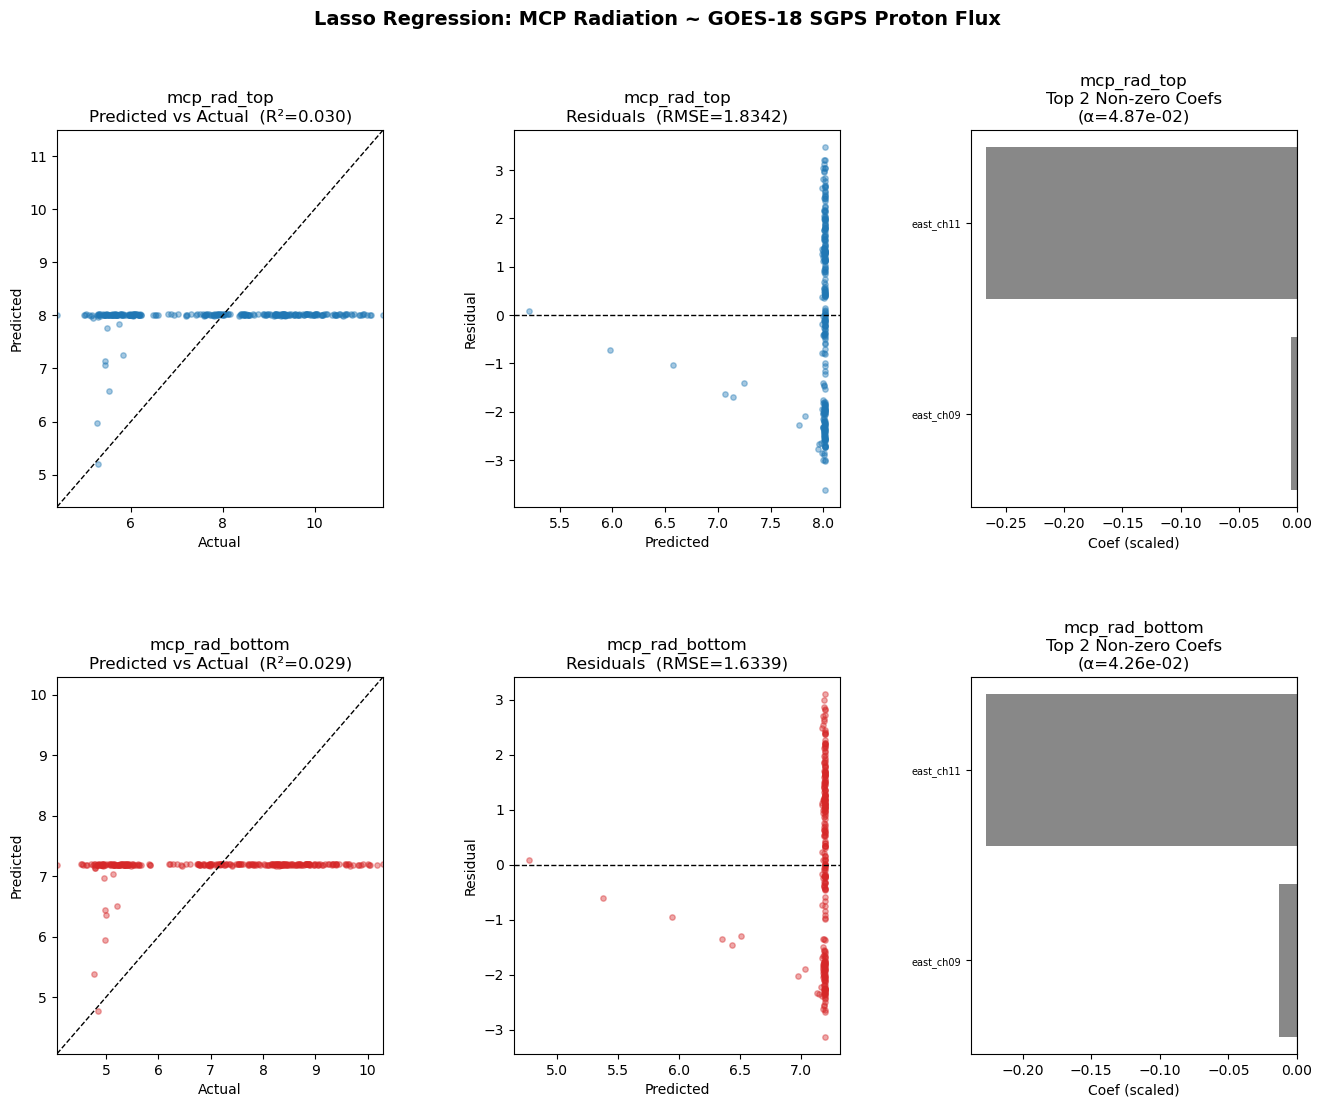


── Summary ──────────────────────────────────────────────
Target                 α (selected)  Non-zero coef  R² (test)  RMSE (test)
--------------------------------------------------------------------------
mcp_rad_top                0.048651              2     0.0299       1.8342
mcp_rad_bottom             0.042613              2     0.0293       1.6339
--------------------------------------------------------------------------


In [ ]:
"""
Lasso Regression: MCP Radiation as a Function of GOES-18 SGPS Proton Flux

Two separate regressions:
  - Dependent variable 1: mcp_rad_top
  - Dependent variable 2: mcp_rad_bottom

Independent variables (features):
  - proton_diff_flux_west  : shape (N, 13)  — 13 differential energy channels, SGPS-X
  - proton_diff_flux_east  : shape (N, 13)  — 13 differential energy channels, SGPS+X
  - proton_int_flux[:,0]   : shape (N,)     — integral flux, west
  - proton_int_flux[:,1]   : shape (N,)     — integral flux, east

Usage
-----
Replace the "── LOAD YOUR DATA ──" block with however you load your arrays,
then run:
    python lasso_mcp_regression.py
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


# ──────────────────────────────────────────────────────────────────────────────
# ── LOAD YOUR DATA ────────────────────────────────────────────────────────────
# Replace this section with your actual data loading code.
# ──────────────────────────────────────────────────────────────────────────────

# Example: loading from a .npz file
# data = np.load("goes18_mcp_data.npz", allow_pickle=True)
# time                  = data["time"]
# proton_diff_flux_west = np.ma.MaskedArray(data["proton_diff_flux_west"])
# proton_diff_flux_east = np.ma.MaskedArray(data["proton_diff_flux_east"])
# proton_int_flux       = np.ma.MaskedArray(data["proton_int_flux"])
# mcp_rad_top           = data["mcp_rad_top"]
# mcp_rad_bottom        = data["mcp_rad_bottom"]

# ──────────────────────────────────────────────────────────────────────────────
# ── 1. BUILD FEATURE MATRIX ──────────────────────────────────────────────────
# ──────────────────────────────────────────────────────────────────────────────

def build_feature_matrix(
    proton_diff_flux_west: np.ma.MaskedArray,
    proton_diff_flux_east: np.ma.MaskedArray,
    proton_int_flux: np.ma.MaskedArray,
) -> tuple[np.ndarray, list[str]]:
    """
    Horizontally stack all predictor arrays into a single (N, 28) feature matrix.
    Masked values are filled with NaN so we can detect and drop bad rows later.

    Returns
    -------
    X : np.ndarray, shape (N, 28)
    feature_names : list[str]
    """
    west_filled  = np.ma.filled(proton_diff_flux_west, fill_value=np.nan)   # (N,13)
    east_filled  = np.ma.filled(proton_diff_flux_east, fill_value=np.nan)   # (N,13)
    int_w_filled = np.ma.filled(proton_int_flux[:, 0], fill_value=np.nan).reshape(-1, 1)
    int_e_filled = np.ma.filled(proton_int_flux[:, 1], fill_value=np.nan).reshape(-1, 1)

    X = np.hstack([west_filled, east_filled, int_w_filled, int_e_filled])

    feature_names = (
        [f"diff_flux_west_ch{i+1:02d}" for i in range(13)] +
        [f"diff_flux_east_ch{i+1:02d}" for i in range(13)] +
        ["int_flux_west", "int_flux_east"]
    )
    return X, feature_names


X_all, feature_names = build_feature_matrix(
    proton_diff_flux_west, proton_diff_flux_east, proton_int_flux
)
print(f"Feature matrix shape : {X_all.shape}")


# ──────────────────────────────────────────────────────────────────────────────
# ── 2. MASK INVALID ROWS (NaN in X or y) ────────────────────────────────────
# ──────────────────────────────────────────────────────────────────────────────

def valid_mask(*arrays: np.ndarray) -> np.ndarray:
    """Return boolean mask of rows that are finite in ALL provided arrays."""
    combined = np.column_stack([a.ravel() if a.ndim == 1 else a for a in arrays])
    return np.all(np.isfinite(combined), axis=1)


# ──────────────────────────────────────────────────────────────────────────────
# ── 3. LASSO REGRESSION FUNCTION ─────────────────────────────────────────────
# ──────────────────────────────────────────────────────────────────────────────

def run_lasso(
    X: np.ndarray,
    y: np.ndarray,
    target_name: str,
    feature_names: list[str],
    test_size: float = 0.2,
    cv: int = 5,
    n_alphas: int = 100,
    random_state: int = 42,
) -> dict:
    """
    Fit a Lasso regression with cross-validated alpha selection.

    Pipeline: StandardScaler → LassoCV

    Parameters
    ----------
    X            : predictor matrix, shape (N, p)
    y            : target vector, shape (N,)
    target_name  : label used in printed output / plots
    feature_names: list of p strings
    test_size    : fraction of data held out for evaluation
    cv           : number of CV folds for alpha selection
    n_alphas     : number of alpha candidates on the log grid
    random_state : for reproducibility of train/test split

    Returns
    -------
    results : dict with keys
        model, scaler, alpha, coef, intercept,
        y_test, y_pred, r2, rmse, feature_names,
        target_name
    """
    # --- drop rows with any NaN ---
    mask = valid_mask(X, y)
    X_clean, y_clean = X[mask], y[mask]
    n_dropped = (~mask).sum()
    if n_dropped:
        print(f"  [{target_name}] Dropped {n_dropped} rows with NaN/masked values.")

    # --- train / test split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=test_size, random_state=random_state
    )

    # --- pipeline: scale → lasso ---
    scaler = StandardScaler()
    lasso  = LassoCV(
        cv=cv,
        n_alphas=n_alphas,
        max_iter=10_000,
        random_state=random_state,
    )
    pipe = Pipeline([("scaler", scaler), ("lasso", lasso)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # retrieve un-scaled coefficients for interpretability
    coef      = pipe.named_steps["lasso"].coef_          # coefficients in scaled space
    intercept = pipe.named_steps["lasso"].intercept_
    alpha_sel = pipe.named_steps["lasso"].alpha_

    n_nonzero = np.sum(coef != 0)

    print(f"\n{'='*60}")
    print(f"  Target        : {target_name}")
    print(f"  N samples     : {X_clean.shape[0]}  (train={len(y_train)}, test={len(y_test)})")
    print(f"  Selected α    : {alpha_sel:.6f}")
    print(f"  Non-zero coef : {n_nonzero} / {len(coef)}")
    print(f"  R²  (test)    : {r2:.4f}")
    print(f"  RMSE (test)   : {rmse:.4f}")
    print(f"{'='*60}")

    # Print non-zero coefficients
    nonzero_idx = np.where(coef != 0)[0]
    if len(nonzero_idx):
        print(f"\n  Non-zero Lasso coefficients (scaled):")
        sorted_idx = nonzero_idx[np.argsort(np.abs(coef[nonzero_idx]))[::-1]]
        for i in sorted_idx:
            print(f"    {feature_names[i]:30s}  {coef[i]:+.6f}")
    else:
        print("  All coefficients were shrunk to zero (increase data or reduce alpha).")

    return dict(
        model=pipe, scaler=scaler, alpha=alpha_sel,
        coef=coef, intercept=intercept,
        y_test=y_test, y_pred=y_pred,
        r2=r2, rmse=rmse,
        feature_names=feature_names,
        target_name=target_name,
        n_nonzero=n_nonzero,
    )


# ──────────────────────────────────────────────────────────────────────────────
# ── 4. RUN BOTH REGRESSIONS ──────────────────────────────────────────────────
# ──────────────────────────────────────────────────────────────────────────────

results_top    = run_lasso(X_all, mcp_rad_top,    "mcp_rad_top",    feature_names)
results_bottom = run_lasso(X_all, mcp_rad_bottom, "mcp_rad_bottom", feature_names)


# ──────────────────────────────────────────────────────────────────────────────
# ── 5. DIAGNOSTIC PLOTS ──────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────────────────────────────

def plot_results(res_top: dict, res_bot: dict, save_path: str = "lasso_results.png"):
    fig = plt.figure(figsize=(16, 12))
    fig.suptitle(
        "Lasso Regression: MCP Radiation ~ GOES-18 SGPS Proton Flux",
        fontsize=14, fontweight="bold", y=0.98,
    )
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

    feature_labels = [f.replace("diff_flux_", "").replace("int_flux_", "int_") for f in feature_names]

    for row, res in enumerate([res_top, res_bot]):
        tname = res["target_name"]
        color = "#2077B4" if row == 0 else "#D62728"

        # ── (a) Predicted vs Actual ──────────────────────────────────────────
        ax1 = fig.add_subplot(gs[row, 0])
        lims = [
            min(res["y_test"].min(), res["y_pred"].min()),
            max(res["y_test"].max(), res["y_pred"].max()),
        ]
        ax1.scatter(res["y_test"], res["y_pred"], alpha=0.4, s=15, color=color)
        ax1.plot(lims, lims, "k--", lw=1)
        ax1.set_xlabel("Actual")
        ax1.set_ylabel("Predicted")
        ax1.set_title(f"{tname}\nPredicted vs Actual  (R²={res['r2']:.3f})")
        ax1.set_xlim(lims); ax1.set_ylim(lims)

        # ── (b) Residuals ────────────────────────────────────────────────────
        ax2 = fig.add_subplot(gs[row, 1])
        residuals = res["y_test"] - res["y_pred"]
        ax2.scatter(res["y_pred"], residuals, alpha=0.4, s=15, color=color)
        ax2.axhline(0, color="k", lw=1, ls="--")
        ax2.set_xlabel("Predicted")
        ax2.set_ylabel("Residual")
        ax2.set_title(f"{tname}\nResiduals  (RMSE={res['rmse']:.4f})")

        # ── (c) Coefficient Bar Chart ────────────────────────────────────────
        ax3 = fig.add_subplot(gs[row, 2])
        coef = res["coef"]
        nonzero = np.where(coef != 0)[0]
        if len(nonzero):
            sorted_idx = nonzero[np.argsort(np.abs(coef[nonzero]))[::-1]][:15]  # top-15
            vals  = coef[sorted_idx]
            labs  = [feature_labels[i] for i in sorted_idx]
            bar_colors = [color if v > 0 else "#888888" for v in vals]
            ax3.barh(range(len(vals)), vals[::-1], color=bar_colors[::-1])
            ax3.set_yticks(range(len(vals)))
            ax3.set_yticklabels(labs[::-1], fontsize=7)
            ax3.axvline(0, color="k", lw=0.8)
            ax3.set_xlabel("Coef (scaled)")
            ax3.set_title(f"{tname}\nTop {len(sorted_idx)} Non-zero Coefs\n(α={res['alpha']:.2e})")
        else:
            ax3.text(0.5, 0.5, "All coef = 0", ha="center", va="center", transform=ax3.transAxes)
            ax3.set_title(f"{tname}\nCoefficients")

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"\nPlot saved → {save_path}")
    plt.show()


plot_results(results_top, results_bottom, save_path="lasso_results.png")


# ──────────────────────────────────────────────────────────────────────────────
# ── 6. SUMMARY TABLE ─────────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────────────────────────────

print("\n── Summary ──────────────────────────────────────────────")
print(f"{'Target':<20} {'α (selected)':>14} {'Non-zero coef':>14} {'R² (test)':>10} {'RMSE (test)':>12}")
print("-" * 74)
for res in [results_top, results_bottom]:
    print(
        f"{res['target_name']:<20} "
        f"{res['alpha']:>14.6f} "
        f"{res['n_nonzero']:>14d} "
        f"{res['r2']:>10.4f} "
        f"{res['rmse']:>12.4f}"
    )
print("-" * 74)